In [93]:
import pandas as pd
import numpy as np
import kaiwu as kw
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
import matplotlib.patches as mpatches
import matplotlib.cm as cm
# Seaborn主题
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimSun'] 
plt.rcParams['axes.unicode_minus'] = False

# 问题一

> 读取参考算例.xlsx的第二个表单，设置为旅行时间矩阵

In [94]:
# 读取第二个表单，跳过第一行
excel_path = 'v1/参考算例.xlsx'
xl = pd.ExcelFile(excel_path)
sheet_names = xl.sheet_names
target_sheet = sheet_names[1]
df = pd.read_excel(excel_path, sheet_name=target_sheet, header=0)
# 转换为numpy数组, 前15节点
travel_time_matrix = df.iloc[0:15, 1:16].values
travel_time_matrix

array([[0, 2, 2, 3, 3, 3, 1, 3, 3, 4, 3, 4, 2, 1, 4],
       [2, 0, 4, 2, 4, 4, 3, 3, 4, 2, 2, 3, 2, 3, 6],
       [2, 4, 0, 4, 3, 3, 2, 5, 5, 6, 6, 7, 3, 1, 3],
       [3, 2, 4, 0, 3, 6, 4, 5, 6, 2, 4, 5, 1, 4, 7],
       [3, 4, 3, 3, 0, 5, 4, 6, 7, 5, 6, 7, 2, 3, 5],
       [3, 4, 3, 6, 5, 0, 1, 3, 2, 7, 4, 5, 5, 2, 3],
       [1, 3, 2, 4, 4, 1, 0, 3, 3, 6, 4, 5, 3, 1, 3],
       [3, 3, 5, 5, 6, 3, 3, 0, 2, 5, 2, 2, 4, 4, 5],
       [3, 4, 5, 6, 7, 2, 3, 2, 0, 6, 3, 3, 5, 4, 4],
       [4, 2, 6, 2, 5, 7, 6, 5, 6, 0, 3, 5, 3, 6, 8],
       [3, 2, 6, 4, 6, 4, 4, 2, 3, 3, 0, 1, 4, 5, 7],
       [4, 3, 7, 5, 7, 5, 5, 2, 3, 5, 1, 0, 6, 5, 7],
       [2, 2, 3, 1, 2, 5, 3, 4, 5, 3, 4, 6, 0, 3, 6],
       [1, 3, 1, 4, 3, 2, 1, 4, 4, 6, 5, 5, 3, 0, 3],
       [4, 6, 3, 7, 5, 3, 3, 5, 4, 8, 7, 7, 6, 3, 0]])

In [95]:
w = travel_time_matrix
n = w.shape[0]
max_w = np.max(w)
w_normalized = w / max_w


x = kw.core.ndarray((n, n), "x", kw.core.Binary)
edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]
no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]

def is_edge_used(x, u, v):
    return kw.core.quicksum([x[u, j] * x[v, j + 1] for j in range(-1, n - 1)])

penalty = 2.0 
qubo_model = kw.qubo.QuboModel()
# TSP时间成本目标函数
qubo_model.set_objective(kw.core.quicksum([w_normalized[u, v] * is_edge_used(x, u, v) for u, v in edges]))

# 约束1：每个位置只能有一个节点
qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "sequence_cons", penalty=penalty)

# 约束2：每个节点只能出现在一个位置
qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "node_cons", penalty=penalty)

# 约束3：禁止使用不存在的边
qubo_model.add_constraint(kw.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges]),
    "connect_cons", penalty=penalty)

In [96]:
worker = kw.classical.SimulatedAnnealingOptimizer(initial_temperature=100,
                                                                         alpha=0.99,
                                                                         cutoff_temperature=0.001,
                                                                         iterations_per_t=100,
                                                                         size_limit=100,
                                                                         flag_evolution_history=True,
                                                                         rand_seed=42)
# 运行模拟退火算法求解QUBO模型
solver = kw.solver.SimpleSolver(worker)
sol_dict, qubo_val = solver.solve_qubo(qubo_model)


In [97]:
# 检查约束是否满足
unsatisfied_count, res_dict = qubo_model.verify_constraint(sol_dict)

# 计算时间成本
path_val = kw.core.get_val(qubo_model.objective, sol_dict)
# 获取历史哈密顿值
hamilton_val = worker.get_ha_history()

if unsatisfied_count == 0:
    # 获取矩阵值
    x_val = kw.core.get_array_val(x, sol_dict)
    # 获取非零元素的索引
    nonzero_index = np.array(np.nonzero(x_val.T))[1]
else:
    print('invalid path')

# 把哈密顿回路平移了！
idx = np.where(nonzero_index == 0)[0][0]
rotated_path = np.concatenate([nonzero_index[idx:], nonzero_index[:idx]])
complete_path = np.concatenate([rotated_path, [0]])
print('时间成本:{}'.format(path_val))
print("未满足的约束数量:", unsatisfied_count)
print("约束项的值:", res_dict)
print('完整路径: {}'.format(complete_path))

时间成本:7.0
未满足的约束数量: 0
约束项的值: {'constraint0': np.float64(0.0), 'constraint2': np.float64(0.0), 'constraint4': np.float64(0.0), 'constraint6': np.float64(0.0), 'constraint8': np.float64(0.0), 'constraint10': np.float64(0.0), 'constraint12': np.float64(0.0), 'constraint14': np.float64(0.0), 'constraint16': np.float64(0.0), 'constraint18': np.float64(0.0), 'constraint20': np.float64(0.0), 'constraint22': np.float64(0.0), 'constraint24': np.float64(0.0), 'constraint26': np.float64(0.0), 'constraint28': np.float64(0.0), 'constraint15': np.float64(0.0), 'constraint17': np.float64(0.0), 'constraint19': np.float64(0.0), 'constraint21': np.float64(0.0), 'constraint23': np.float64(0.0), 'constraint25': np.float64(0.0), 'constraint27': np.float64(0.0), 'constraint29': np.float64(0.0), 'constraint31': np.float64(0.0), 'constraint33': np.float64(0.0), 'constraint35': np.float64(0.0), 'constraint37': np.float64(0.0), 'constraint39': np.float64(0.0), 'constraint41': np.float64(0.0), 'constraint43': np.

> 导出为csv，用于量子计算

In [98]:
qubo_mat = qubo_model.get_matrix()
qubo = kw.qubo.adjust_qubo_matrix_precision(qubo_mat)
pd.DataFrame(qubo).to_csv("tsp1_qubo.csv", index=False, header=False)

> 哈密顿量演化曲线

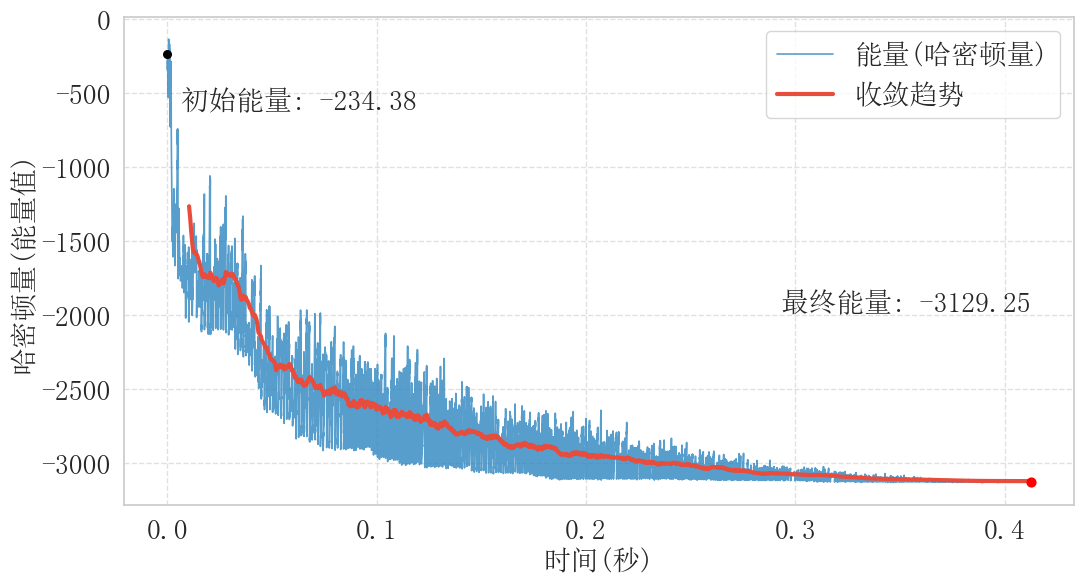

In [99]:
def plot_real_hamiltonian_evolution(hamilton_dict):
    """
    根据hamilton_val字典绘制演化曲线
    hamilton_dict: {时间(秒): 哈密顿量}
    """
    if not hamilton_dict:
        print("Error: hamilton_val变量为空")
        return

    # 提取并按时间排序
    sorted_times = sorted(hamilton_dict.keys())
    energies = [hamilton_dict[t] for t in sorted_times]

    # 创建画布
    plt.figure(figsize=(11, 6))
    
    # 绘制主曲线, 使用实线表示能量变化，由于量子/退火采样点可能很多，线条加细
    plt.plot(sorted_times, energies, color='#2E86C1', linewidth=1.2, alpha=0.8, label='能量(哈密顿量)')
    
    # 绘制平滑趋势线, 使用移动平均
    if len(energies) > 20:
        window = len(energies) // 50
        smooth_energies = np.convolve(energies, np.ones(window)/window, mode='valid')
        plt.plot(sorted_times[window-1:], smooth_energies, color='#E74C3C', linewidth=3, label='收敛趋势')

    # 标注起点和终点
    plt.scatter(sorted_times[0], energies[0], color='black', s=30, zorder=5)
    plt.text(sorted_times[0], energies[0]-400, f' 初始能量: {energies[0]:.2f}', va='bottom', fontsize=20)
    
    plt.scatter(sorted_times[-1], energies[-1], color='red', s=40, zorder=5)
    plt.text(sorted_times[-1], energies[-1]+1300, f' 最终能量: {energies[-1]:.2f}', va='top', ha='right', fontweight='bold', fontsize=20)

    # plt.title('哈密顿量时间演化历史', fontsize=15, pad=20)
    plt.xlabel('时间(秒)', fontsize=20)
    plt.ylabel('哈密顿量(能量值)', fontsize=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    
    # 优化边距
    plt.tight_layout()
    plt.savefig(r"D:\item\pyitem\mathma\figure\哈密顿量时间演化历史1.png", dpi=300)
    plt.show()
    

plot_real_hamiltonian_evolution(hamilton_val)


> 路径可视化图

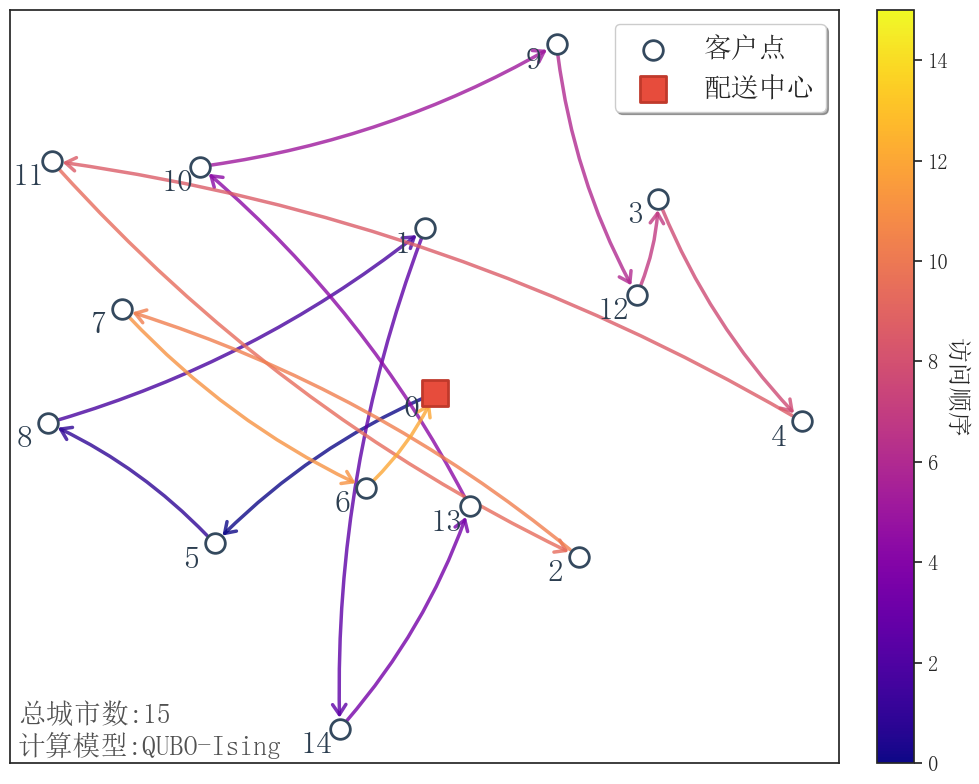

In [100]:
def plot_final_route_pro(w_matrix, path, title="TSP最优路径拓扑分布图"):
    # 设置视觉风格
    sns.set_theme(style="white") # 清爽背景
    plt.rcParams['font.sans-serif'] = ['SimSun'] 
    plt.rcParams['axes.unicode_minus'] = False

    # MDS降维获取坐标
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=10)
    coords = mds.fit_transform((w_matrix + w_matrix.T) / 2)

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # 准备渐变色
    # 使用'plasma'或'viridis'颜色映射，表示路径的先后顺序
    num_steps = len(path) - 1
    colors = cm.plasma(np.linspace(0, 0.8, num_steps)) 

    # 绘制路径，带渐变和箭头
    for i in range(num_steps):
        u, v = path[i], path[i+1]
        start_coord = coords[u]
        end_coord = coords[v]
        
        # 绘制箭头，颜色随顺序变深/变亮
        ax.annotate("", xy=end_coord, xytext=start_coord,
                    arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6",
                                   lw=2.5, color=colors[i], alpha=0.8,
                                   shrinkA=8, shrinkB=8, # 避免箭头刺入节点内部
                                   connectionstyle="arc3,rad=0.1")) # 略微弯曲增加动感

    # 绘制节点
    # 普通客户点
    customer_indices = [i for i in range(len(w_matrix)) if i != 0]
    ax.scatter(coords[customer_indices, 0], coords[customer_indices, 1], 
               c='white', s=200, edgecolors='#34495E', linewidth=2, zorder=3, label='客户点')
    
    # 仓库起点
    ax.scatter(coords[0, 0], coords[0, 1], 
               c='#E74C3C', marker='s', s=350, edgecolors='#C0392B', 
               linewidth=2, zorder=4, label='配送中心')

    # 添加节点编号，优化位置，避免重叠
    for i in range(len(w_matrix)):
        ax.text(coords[i, 0]-0.2, coords[i, 1]-0.3, str(i), 
                fontsize=23, fontweight='bold', ha='center', color='#2C3E50')

    # 添加颜色条展示访问顺序
    sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=plt.Normalize(vmin=0, vmax=num_steps))
    cbar = fig.colorbar(sm, ax=ax, fraction=0.07, pad=0.04)
    cbar.set_label('访问顺序', rotation=270, labelpad=15, fontsize=18)
    cbar.ax.tick_params(labelsize=15)

    # 细节修饰
    # ax.set_title(title, fontsize=18, fontweight='bold', color='#2C3E50')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)

    # 添加左下角信息备注
    ax.text(0.01, 0.01, f"总城市数:{len(w_matrix)}\n计算模型:QUBO-Ising", 
            transform=ax.transAxes, fontsize=20, alpha=0.8)
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=20)
    plt.tight_layout()
    plt.savefig(r"D:\item\pyitem\mathma\figure\TSP最优路径拓扑分布图1.png", dpi=300)
    plt.show()
    

# 运行
plot_final_route_pro(travel_time_matrix, complete_path)